In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits


Model parameters

In [3]:
npt=1000000                 # number of points in simulation

radius_range=[0.0001,1]     # range of radii [arcsec  or other units]
theta_range=[89, 91.]       # range of theta angle [deg]
phi_range=[0, 360.]         # range of phi angle [deg]

logradius= False             # radius with logarithmic sampling?

xycenter = [0.,0.]          # projected center position on sky plane

# Euler angles
alpha = 0    # not important if axially symmetric around z ...
beta = 60.   #  ~ inclination w.r.t. line of sight for a disk
gamma = -30. #  ~ position angle of major axis in case of a disk

vsys = 0.                 # systemic velocity [km/s or other units],la componente della velocità lungo la linea di vista dell'osservatore

#  data  cube properties
cube_range = [ [-2000,2000], [-2,2], [-2,2] ]   # velocity, y, x ranges in v, x,  y units
cube_nbins = [ 161, 81, 81 ]                     # number of bins in velocity, y, x 

# oversampling for convolution
oversamp = 4

# PSF
psf_fwhm = 0.3             # Gaussian PSF FWHM in same units as radius, x, y


velstep = (cube_range[0][1]-cube_range[0][0])/(cube_nbins[0]-1)
ystep = (cube_range[1][1]-cube_range[1][0])/(cube_nbins[1]-1)
xstep = (cube_range[2][1]-cube_range[2][0])/(cube_nbins[2]-1)
xpix = cube_range[2][0]+xstep*(np.arange(cube_nbins[2]))
ypix = cube_range[1][0]+ystep*(np.arange(cube_nbins[1]))
velpix = cube_range[0][0]+velstep*(np.arange(cube_nbins[0]))
print(velstep, ystep, xstep)
print(velpix)
print(ypix)
print(xpix)

25.0 0.05 0.05
[-2000. -1975. -1950. -1925. -1900. -1875. -1850. -1825. -1800. -1775.
 -1750. -1725. -1700. -1675. -1650. -1625. -1600. -1575. -1550. -1525.
 -1500. -1475. -1450. -1425. -1400. -1375. -1350. -1325. -1300. -1275.
 -1250. -1225. -1200. -1175. -1150. -1125. -1100. -1075. -1050. -1025.
 -1000.  -975.  -950.  -925.  -900.  -875.  -850.  -825.  -800.  -775.
  -750.  -725.  -700.  -675.  -650.  -625.  -600.  -575.  -550.  -525.
  -500.  -475.  -450.  -425.  -400.  -375.  -350.  -325.  -300.  -275.
  -250.  -225.  -200.  -175.  -150.  -125.  -100.   -75.   -50.   -25.
     0.    25.    50.    75.   100.   125.   150.   175.   200.   225.
   250.   275.   300.   325.   350.   375.   400.   425.   450.   475.
   500.   525.   550.   575.   600.   625.   650.   675.   700.   725.
   750.   775.   800.   825.   850.   875.   900.   925.   950.   975.
  1000.  1025.  1050.  1075.  1100.  1125.  1150.  1175.  1200.  1225.
  1250.  1275.  1300.  1325.  1350.  1375.  1400.  1425.  1450

Define Flux and Velocity model

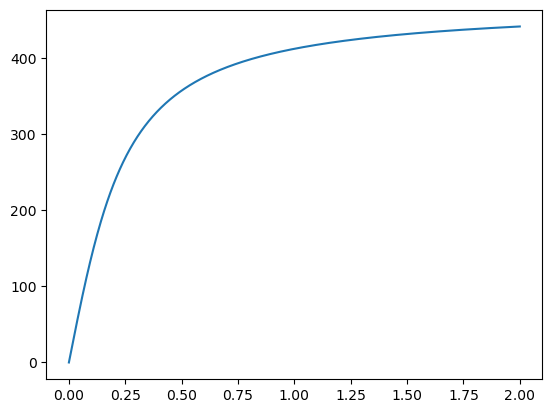

In [4]:
# cloud flux as a function of radius, theta, phi
def flux_func(radius, theta, phi, params):
    F0, R0 = params
    
    return F0*np.exp(-radius/R0)

# cloud velocity components as a function of radius, theta, phi
def vr_func(radius, theta, phi, params):
    
    return radius*0.

def vth_func(radius, theta, phi, params):
    
    return radius*0.

def vph_func(radius, theta, phi, params):
    V0, R0 = params
    
    # Keplerian
    #return V0*(radius/R0)**(-0.5)
    # Dark Halo
    return V0*np.arctan(radius/R0)

# Flux parameters
F0 = 1.0
RF0 = 0.2

params_flux = [ F0, RF0 ]

# Velocity parameters
V0 = 300.
RV0 = 0.2

params_vel = [ V0, RV0 ]

r = np.linspace(0, 2, 1000)
plt.plot(r, vph_func(r, r*0., r*0., params_vel))

Define random points with spherical coordinates (radius, theta, phi)

In [5]:
# non-uniform distribution but assign weights for histogramdd

# generate random uniform theta array with npts element
theta = np.random.uniform(low=np.radians(theta_range[0]), high=np.radians(theta_range[1]), size=npt) 

# generate random uniform phi array with npts element
phi = np.random.uniform(low=np.radians(phi_range[0]), high=np.radians(phi_range[1]), size=npt)
                        
                        
# generate random uniform radius array with npts element in linear or logarithmic space
if logradius:
    radius = 10**(np.random.uniform(low=np.log10(radius_range[0]), high=np.log10(radius_range[1]), size=npt))
    # multiply by rad**2 to make it constant if n(logr) = const.
    flux_radius = radius**2*np.abs(np.sin(theta))/npt*2.
else:
    # non-uniform distribution but assign weights for histogramdd
    # multiply by rad to make it constant if n(r) = const.
    radius = np.random.uniform(low=radius_range[0], high=radius_range[1], size=npt)
    flux_radius = radius*np.abs(np.sin(theta))/npt*2.


Compute unit vectors of spherical coordinates ur, uth, uphi at each random point; 

find ur, uth, uphi cartesian components

compute position vector cartesian components for each point

In [6]:
def coords(r, th, ph):

    sinth = np.sin(th)
    costh = np.cos(th)
    sinph = np.sin(ph)
    cosph = np.cos(ph)

    # u_r 
    ur_x = sinth*cosph
    ur_y = sinth*sinph
    ur_z = costh

    # u_theta 
    uth_x = costh*cosph
    uth_y = costh*sinph
    uth_z = -sinth

    # u_phi
    uph_x = -sinph
    uph_y = cosph
    uph_z = np.zeros(sinth.shape)
            
    # R = r*u_r - position vector
    x = r*ur_x
    y = r*ur_y
    z = r*ur_z
    
    return [ [x, y, z], [ur_x, ur_y, ur_z], [uth_x, uth_y, uth_z], [uph_x, uph_y, uph_z]]

P, ur, uth, uph = coords(radius, theta, phi)

x, y, z = P
ur_x, ur_y, ur_z = ur
uth_x, uth_y, uth_z = uth
uph_x, uph_y, uph_z = uph

Compute fluxes anv velocity components at each point position

In [7]:
# cloud fluxes
flux = flux_radius*flux_func(radius, theta, phi, params_flux)        
    
# cloud velocities
velx = np.zeros(npt)        
vely = np.zeros(npt)        
velz = np.zeros(npt)    
        
vr = vr_func(radius, theta, phi, [])
vth = vth_func(radius, theta, phi, [])
vph = vph_func(radius, theta, phi, params_vel)

velx =  vr*ur_x+vth*uth_x+vph*uph_x
vely =  vr*ur_y+vth*uth_y+vph*uph_y
velz =  vr*ur_z+vth*uth_z+vph*uph_z

Rotations with Euler angles

In [8]:
def rotaxx(angle):
    cosa = np.cos(angle)
    sina = np.sin(angle)
    RX = [ [1,     0,     0],
           [0,  cosa,  sina],
           [0, -sina,  cosa] ]
    return np.array(RX)

def rotaxy(angle):
    cosa = np.cos(angle)
    sina = np.sin(angle)
    RY = [ [ cosa, 0, sina],
           [    0, 1,    0],
           [-sina, 0, cosa] ]
    return np.array(RY)
    
def rotaxz(angle):
    cosa = np.cos(angle)
    sina = np.sin(angle)
    RZ = [ [ cosa, sina,  0],
           [-sina, cosa,  0],
           [    0,    0,  1] ]
    return np.array(RZ)
    
def eulermat(alpha, beta, gamma):
    # 1. rotation of alpha around z axis
    EM = rotaxz(alpha)
    # 2. rotation of beta around x axis
    EM = np.dot(rotaxx(beta), EM)
    # 3. rotation of gamma around z axis
    EM = np.dot(rotaxz(gamma), EM)
    return EM

def eulermat_inverse(alpha, beta, gamma):
    # 3. rotation of -gamma around z axis
    EMI = rotaxz(-gamma)
    # 2. rotation of -beta around x axis
    EMI = np.dot(rotaxx(-beta), EMI)
    # 1. rotation of -alpha around z axis
    EMI = np.dot(rotaxz(-alpha), EMI)
    return EMI

Example with Euler Angles

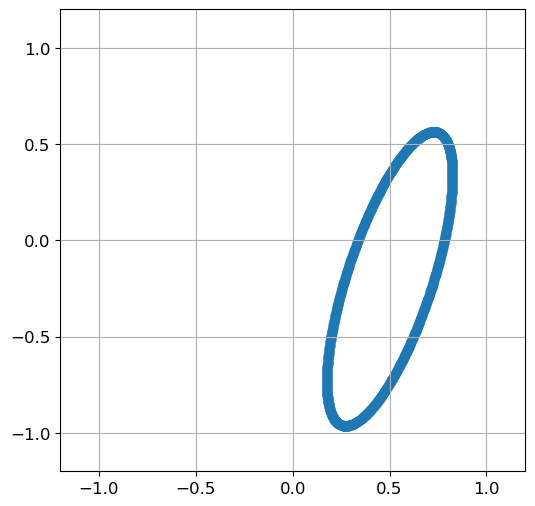

In [14]:
nr = 1000

rmax = 0.8

# ring
r = np.zeros(nr)+rmax
th = np.radians(90.)
ph = np.linspace(0, 2*np.pi, nr)

# spiral
#th = np.radians(np.linspace(0, 90, nr))
#ph = np.linspace(0, 20*np.pi, nr)

P, ur, uth, uph = coords(r, th, ph)

xp, yp, zp = P

xalpha =  0
xbeta = 74
xgamma = 288
Pref = np.stack([xp, yp, zp])
Pobs = np.dot(eulermat(np.radians(xalpha), np.radians(xbeta), np.radians(xgamma)), Pref)

Pobs[0,:] = Pobs[0,:] + 0.5
Pobs[1,:] = Pobs[1,:] - 0.2


plt.rcParams['figure.figsize'] = [6, 6]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

plt.scatter(Pobs[0,:], Pobs[1,:])
#plt.axis('equal')
plt.xlim(-rmax*1.5,rmax*1.5)
plt.ylim((-rmax*1.5,rmax*1.5))
plt.grid()

Observe clouds

In [10]:
# from system to sky coordinates (zobs along line fo sight)
Pref = np.stack([x, y, z])
Pobs = np.dot(eulermat(np.radians(alpha), np.radians(beta), np.radians(gamma)), Pref)

xobs = Pobs[0,:]+xycenter[0]
yobs = Pobs[1,:]+xycenter[1]
zobs = Pobs[2,:]

# Zobs unit vector of line of sight --> Zref in source reference
Zobs = np.array([0., 0., -1.]).transpose() # k vector in observed frame (line of sight)
Zref = np.dot(eulermat_inverse(np.radians(alpha), np.radians(beta), np.radians(gamma)), Zobs)
# Velocity along line of sight
Vref = np.stack([velx, vely, velz])      
# also add systemic velocity
vlos = np.dot(Zref,Vref)+vsys

Generate cube

In [11]:
data = np.vstack([vlos, yobs, xobs]).T # V, Y, X
cube, edges = np.histogramdd(data, bins=cube_nbins, range=cube_range, weights=flux)

# save to fits  file
hdu = fits.PrimaryHDU(cube)
# write header values for xis coordinates
hdu.header['CD1_1'] = xstep
hdu.header['CD2_2'] = ystep
hdu.header['CD3_3'] = velstep
hdu.header['CRPIX1'] = 1
hdu.header['CRPIX2'] = 1
hdu.header['CRPIX3'] = 1
hdu.header['CRVAL1'] = cube_range[2][0]
hdu.header['CRVAL2'] = cube_range[1][0]
hdu.header['CRVAL3'] = cube_range[0][0]

hdul = fits.HDUList([hdu])
hdul.writeto('mod.fits', overwrite=True)

In [12]:
velvec = cube_range[0][0]+velstep*np.arange(cube_nbins[0])

velcube = np.repeat(velvec[:,np.newaxis], cube_nbins[1], axis=1)
velcube = np.repeat(velcube[:,:,np.newaxis], cube_nbins[2], axis=2)

# flux map
map_flux = np.sum(cube, axis=0)
fmax = 1e-3

w = map_flux < fmax*np.max(map_flux)
map_flux[w] = np.nan

# vel map
map_vel = np.nansum(velcube*cube, axis=0)/map_flux

# sig map
velav2 = np.nansum(velcube**2*cube, axis=0)/map_flux
map_sig = (velav2-map_vel**2)**0.5

print(velcube.shape)

extent = [ xpix[0]-xstep/2., xpix[-1]+xstep/2., ypix[0]-ystep/2., ypix[-1]+ystep/2.]

(161, 81, 81)


C:\Users\39351\AppData\Local\Temp\ipykernel_23772\2378469342.py:18: RuntimeWarning: invalid value encountered in sqrt
  map_sig = (velav2-map_vel**2)**0.5


In [13]:
print("map_flux:", map_flux)

map_flux: [[nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 ...
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]
 [nan nan nan ... nan nan nan]]


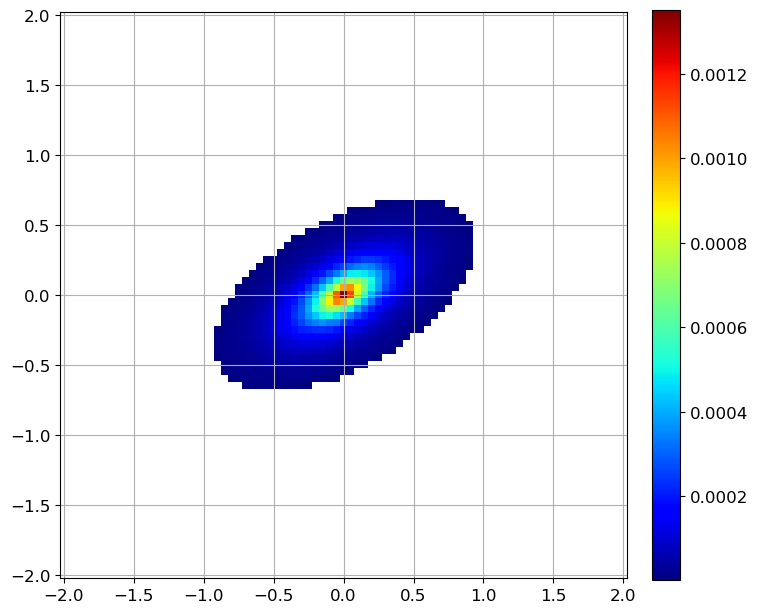

In [12]:
plt.rcParams['figure.figsize'] = [8, 8]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

plt.imshow(map_flux, origin='lower', vmin=None, vmax=None, extent=extent, cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.grid()


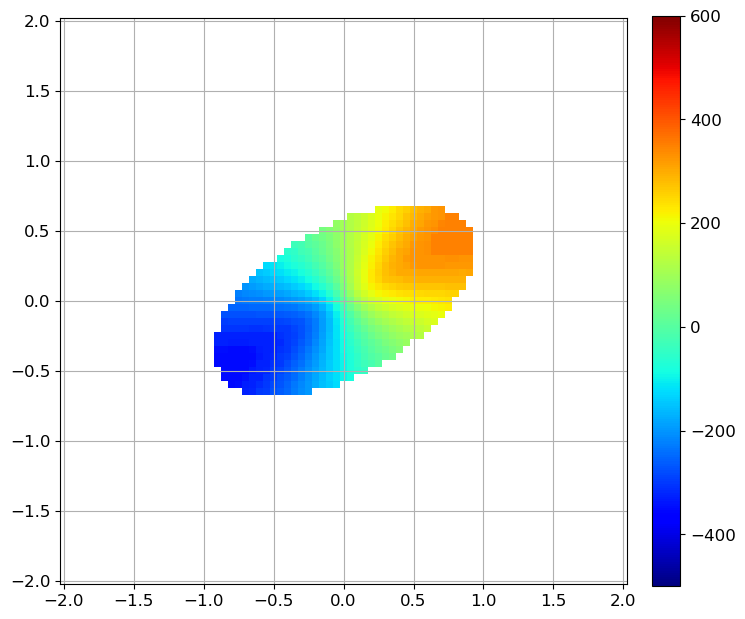

In [13]:
plt.imshow(map_vel, origin='lower', vmin=-500, vmax=600, extent=extent, cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.grid()


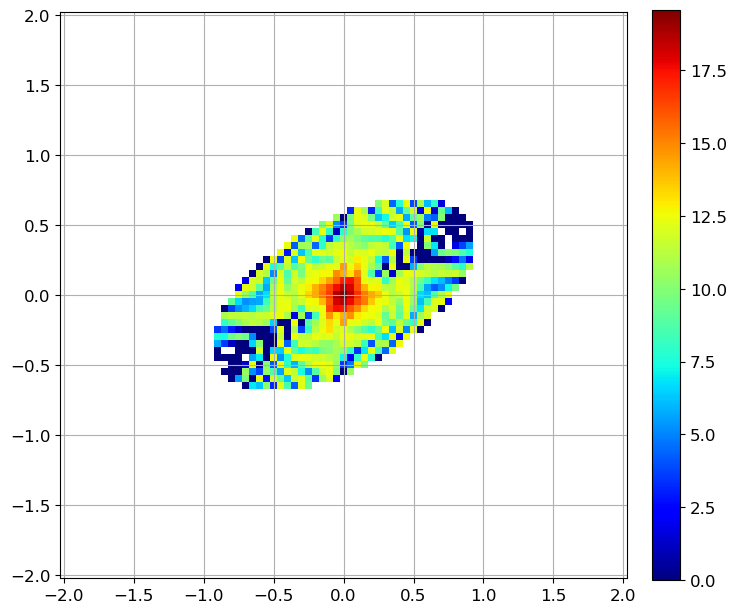

In [14]:
plt.imshow(map_sig, origin='lower', vmin=None, vmax=None, extent=extent, cmap='jet')
plt.colorbar(fraction=0.046, pad=0.04)
plt.grid()


Convolve with PSF

Oversample before convolution: instead of using final image size NX x NY, first use (oversample x NX) x (oversample  x NY) image with steps XSTEP/Oversample, YSTEP/oversample; do the convolution and after that rebin to NX x NY image with  XSTEP, YSTEP; convolution is more accurate  with finer sampling (recall that we are working on a grid not non a continuos space)

In [15]:
data = np.vstack([vlos, yobs, xobs]).T # V, Y, X
cubep, edges = np.histogramdd(data, bins=[cube_nbins[0], cube_nbins[1]*oversamp, cube_nbins[2]*oversamp], range=cube_range, weights=flux)

from astropy.convolution import convolve
from astropy.convolution import Gaussian2DKernel
from tqdm import tqdm

psf = Gaussian2DKernel(x_stddev=oversamp*psf_fwhm/xstep/2.355, y_stddev=oversamp*psf_fwhm/ystep/2.355)

# rebin 2d array by replacing by(along rows)*bx(along cols) pixels by sum
def rebin(array, by, bx):
    rows = array.shape[0]
    cols = array.shape[1]
    return np.nansum(np.nansum(array.reshape(rows // by, by, cols // bx, bx), axis=3), axis=1)

cube_conv = cube*0.

for i in tqdm(range(cube_nbins[0])):
    img = cubep[i, :, :]
    img_conv = convolve(img, psf)
    cube_conv[i, :, :] = rebin(img_conv, oversamp, oversamp)
    

100%|██████████| 161/161 [02:11<00:00,  1.22it/s]


In [20]:
velstep = (cube_range[0][1]-cube_range[0][0])/(cube_nbins[0]-1)
velvec = cube_range[0][0]+velstep*np.arange(cube_nbins[0])

velcube = np.repeat(velvec[:,np.newaxis], cube_nbins[1], axis=1)
velcube = np.repeat(velcube[:,:,np.newaxis], cube_nbins[2], axis=2)

# flux map
map_flux_conv = np.sum(cube_conv, axis=0)
fmax = 1e-3

w = map_flux_conv < fmax*np.max(map_flux_conv)
map_flux_conv[w] = np.nan

# flux map
map_vel_conv = np.nansum(velcube*cube_conv, axis=0)/map_flux_conv

# sig map
velav2 = np.nansum(velcube**2*cube_conv, axis=0)/map_flux_conv
map_sig_conv = (velav2-map_vel_conv**2)**0.5


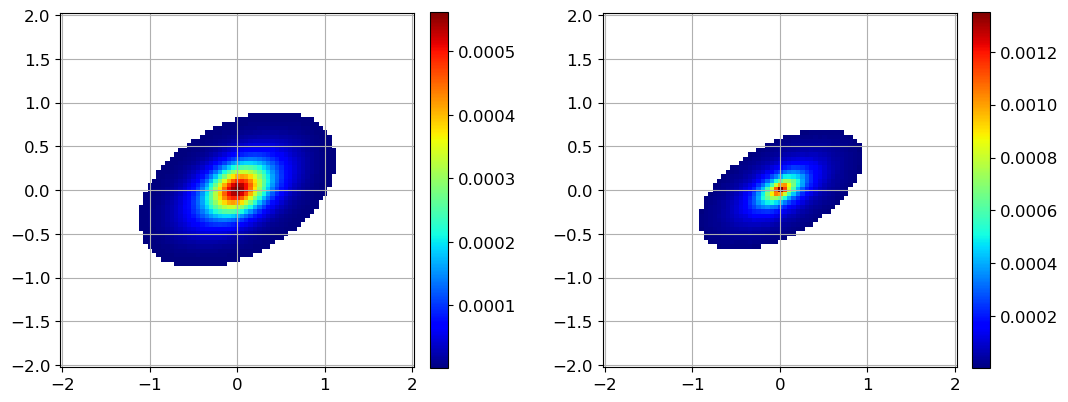

In [21]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi']= 100 # set plot image resolution (dpi)
plt.rcParams.update({'font.size': 12})

fig, (ax1, ax2) = plt.subplots(1,2)
fig.subplots_adjust(wspace=0.4)
                  
cset1 = ax1.imshow(map_flux_conv, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)

cset2 = ax2.imshow(map_flux, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
fig.colorbar(cset2, fraction=0.046, pad=0.04, ax=ax2)
ax2.grid()


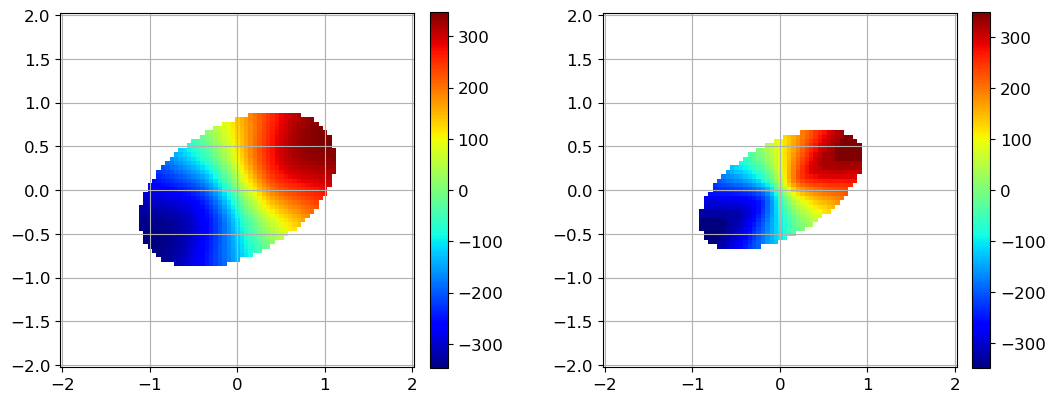

In [22]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.subplots_adjust(wspace=0.4)
                  
cset1 = ax1.imshow(map_vel_conv, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)

cset2 = ax2.imshow(map_vel, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
fig.colorbar(cset2, fraction=0.046, pad=0.04, ax=ax2)
ax2.grid()


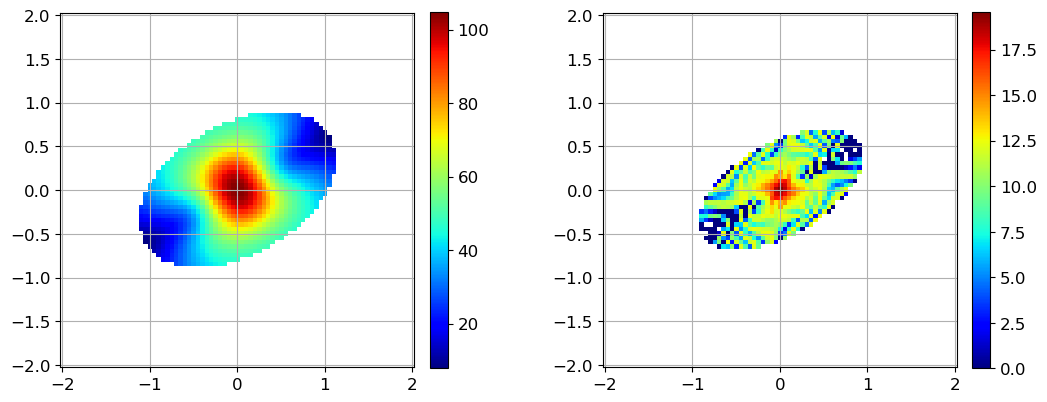

In [23]:
fig, (ax1, ax2) = plt.subplots(1,2)
fig.subplots_adjust(wspace=0.4)
                  
cset1 = ax1.imshow(map_sig_conv, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
ax1.grid()
fig.colorbar(cset1, fraction=0.046, pad=0.04, ax=ax1)

cset2 = ax2.imshow(map_sig, origin='lower',  extent=extent, vmin=None, vmax=None, cmap='jet')
fig.colorbar(cset2, fraction=0.046, pad=0.04, ax=ax2)
ax2.grid()
